In [ ]:
import json
import math
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import yaml
from google.colab import drive
from sklearn.metrics import roc_auc_score
from torch.utils.data import DataLoader, Subset
from torchvision import models, transforms
from torchvision.datasets import CIFAR10, CIFAR100
from tqdm.auto import tqdm

drive.mount("/content/drive")

PROJECT_DIR="/content/drive/MyDrive/ATML-PA1"
DATA_ROOT=PROJECT_DIR+"/data"
os.makedirs(DATA_ROOT,exist_ok=True)
for folder in ["configs","results/checkpoints","results/figures"]:
    os.makedirs(PROJECT_DIR+"/task4/"+folder,exist_ok=True)
os.chdir(PROJECT_DIR)

if torch.cuda.is_available():
    DEVICE=torch.device("cuda")
else:
    DEVICE=torch.device("cpu")

torch.backends.cudnn.deterministic=True
torch.backends.cudnn.benchmark=False

print(torch.__version__,DEVICE,os.getcwd())
if DEVICE.type=="cuda":
    print(torch.cuda.get_device_name(0))

Mounted at /content/drive
2.11.0+cpu cpu /content/drive/MyDrive/ATML-PA1


In [ ]:
%%writefile task4/configs/task4.yaml
seed: 6304
known_dataset: cifar10
val_fraction: 0.1 #stratified 90/10
epochs: 100
batch_size: 128
learning_rate: 0.1
momentum: 0.9
weight_decay: 0.0005
proser_epochs: 50
proser_learning_rate: 0.001
proser_dummy_count: 5
proser_beta: 1.0 #classifier-placeholder weight
proser_gamma: 0.1 #data-placeholder weight
mixup_alpha: 2.0 #lambda ~ Beta(2,2)
accept_percentile: 95

Overwriting task4/configs/task4.yaml


In [ ]:
CONFIG=yaml.safe_load(open("task4/configs/task4.yaml"))
SEED=CONFIG["seed"]
BATCH_SIZE=CONFIG["batch_size"]

CIFAR_MEAN=(0.4914,0.4822,0.4465)
CIFAR_STD=(0.2470,0.2435,0.2616)

TRAIN_TRANSFORM=transforms.Compose([
    transforms.RandomCrop(32,padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN,CIFAR_STD)])

GCSC_TRANSFORM=transforms.Compose([
    transforms.RandomCrop(32,padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2,magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN,CIFAR_STD)])

EVAL_TRANSFORM=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN,CIFAR_STD)])

NEAR_CLASSES=["bus","pickup_truck","motorcycle","tractor","wolf","fox","leopard","camel"]
FAR_CLASSES=["bottle","bowl","chair","clock","keyboard","mushroom","sunflower","wardrobe"]

cifar10_train_raw=CIFAR10(root=DATA_ROOT,train=True,download=True)
cifar10_test_raw=CIFAR10(root=DATA_ROOT,train=False,download=True)
KNOWN_CLASSES=list(cifar10_train_raw.classes)
print("known classes:",KNOWN_CLASSES)


def stratified_split(labels,val_fraction,seed):
    random_state=np.random.RandomState(seed)
    labels=np.array(labels)
    train_indices=[]
    val_indices=[]
    for class_index in sorted(set(labels.tolist())):
        members=random_state.permutation(np.where(labels==class_index)[0])
        validation_count=int(round(len(members)*val_fraction))
        val_indices.extend(members[0:validation_count].tolist())
        train_indices.extend(members[validation_count:].tolist())
    return sorted(train_indices),sorted(val_indices)


TRAIN_INDICES,VAL_INDICES=stratified_split(cifar10_train_raw.targets,CONFIG["val_fraction"],SEED)
print(f"cifar-10 train {len(TRAIN_INDICES)}  val {len(VAL_INDICES)}  test {len(cifar10_test_raw)}")

cifar100_test_raw=CIFAR100(root=DATA_ROOT,train=False,download=True)
CIFAR100_CLASSES=list(cifar100_test_raw.classes)
cifar100_targets=np.array(cifar100_test_raw.targets)
for class_name in NEAR_CLASSES+FAR_CLASSES:
    assert class_name in CIFAR100_CLASSES,f"{class_name} is not a cifar-100 fine label"

UNKNOWN_INDICES={}
UNKNOWN_CLASS_NAMES={}
for group_name,group_classes in [("near",NEAR_CLASSES),("far",FAR_CLASSES)]:
    rows=[]
    names=[]
    for class_name in group_classes:
        members=np.where(cifar100_targets==CIFAR100_CLASSES.index(class_name))[0]
        rows.extend(members.tolist())
        for position in range(len(members)):
            names.append(class_name)
    UNKNOWN_INDICES[group_name]=rows
    UNKNOWN_CLASS_NAMES[group_name]=names
    print(f"{group_name:<5} unknown {len(rows)} images from {len(group_classes)} classes")
    assert len(rows)==800

UNKNOWNS_UNLOCKED=False


def require_unlocked():
    if UNKNOWNS_UNLOCKED==False:
        raise RuntimeError("cifar-100 unknowns are still locked")


def unlock_unknowns():
    global UNKNOWNS_UNLOCKED
    for method in ["vanilla","gcsc","proser"]:
        path=f"task4/results/checkpoints/{method}.pt"
        if os.path.exists(path)==False:
            raise RuntimeError(f"{path} is missing, training is not finished")
    UNKNOWNS_UNLOCKED=True
    print("cifar-100 unknowns unlocked, all three checkpoints exist")

known classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
cifar-10 train 45000  val 5000  test 10000
near  unknown 800 images from 8 classes
far   unknown 800 images from 8 classes


In [ ]:
def build_cifar_resnet18():
    model=models.resnet18(weights=None)
    model.conv1=nn.Conv2d(3,64,kernel_size=3,stride=1,padding=1,bias=False)
    model.maxpool=nn.Identity()
    model.fc=nn.Linear(512,len(KNOWN_CLASSES))
    return model.to(DEVICE)


def stem_to_layer2(model,batch):
    hidden=model.conv1(batch)
    hidden=model.bn1(hidden)
    hidden=model.relu(hidden)
    hidden=model.maxpool(hidden)
    hidden=model.layer1(hidden)
    hidden=model.layer2(hidden)
    return hidden


def layer3_onwards(model,hidden):
    hidden=model.layer3(hidden)
    hidden=model.layer4(hidden)
    feature=hidden.mean(dim=(2,3))
    return feature,model.fc(feature)


def features_and_logits(model,batch):
    return layer3_onwards(model,stem_to_layer2(model,batch))


def seed_worker(worker_id):
    worker_seed=SEED+worker_id
    np.random.seed(worker_seed)
    torch.manual_seed(worker_seed)


def make_loader(dataset,indices,shuffle,batch_size=BATCH_SIZE):
    generator=torch.Generator()
    generator.manual_seed(SEED)
    return DataLoader(Subset(dataset,indices),batch_size=batch_size,shuffle=shuffle,
                      num_workers=2,generator=generator,worker_init_fn=seed_worker,drop_last=False)


def accuracy_on(model,loader):
    model.eval()
    correct=0
    total=0
    with torch.no_grad():
        for images,labels in loader:
            images=images.to(DEVICE)
            labels=labels.to(DEVICE)
            _,logits=features_and_logits(model,images)
            correct=correct+int((logits.argmax(1)==labels).sum())
            total=total+len(labels)
    return correct/total

In [ ]:
EPOCHS=CONFIG["epochs"]


def train_closed_set(method):
    torch.manual_seed(SEED)
    np.random.seed(SEED)

    if method=="gcsc":
        train_transform=GCSC_TRANSFORM
    else:
        train_transform=TRAIN_TRANSFORM

    train_dataset=CIFAR10(root=DATA_ROOT,train=True,download=False,transform=train_transform)
    val_dataset=CIFAR10(root=DATA_ROOT,train=True,download=False,transform=EVAL_TRANSFORM)
    train_loader=make_loader(train_dataset,TRAIN_INDICES,True)
    val_loader=make_loader(val_dataset,VAL_INDICES,False,batch_size=512)

    model=build_cifar_resnet18()
    optimizer=torch.optim.SGD(model.parameters(),lr=CONFIG["learning_rate"],
                              momentum=CONFIG["momentum"],weight_decay=CONFIG["weight_decay"])
    scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=EPOCHS)
    criterion=nn.CrossEntropyLoss()

    history=[]
    best_accuracy=-1.0
    best_state=None
    for epoch in range(EPOCHS):
        model.train()
        loss_sum=0.0
        batch_count=0
        for images,labels in train_loader:
            images=images.to(DEVICE)
            labels=labels.to(DEVICE)
            optimizer.zero_grad()
            _,logits=features_and_logits(model,images)
            loss=criterion(logits,labels)
            loss.backward()
            optimizer.step()
            loss_sum=loss_sum+float(loss.detach())
            batch_count=batch_count+1
        scheduler.step()

        validation_accuracy=accuracy_on(model,val_loader)
        history.append({"epoch":epoch+1,"train_loss":loss_sum/batch_count,
                        "val_accuracy":validation_accuracy})
        #selection uses cifar-10 validation accuracy
        if validation_accuracy>best_accuracy:
            best_accuracy=validation_accuracy
            best_state={}
            for key,value in model.state_dict().items():
                best_state[key]=value.clone()
        if (epoch+1)%10==0 or epoch==0:
            print(f"{method} epoch {epoch+1:>3}  loss {loss_sum/batch_count:.4f}  "
                  f"val {validation_accuracy:.4f}  best {best_accuracy:.4f}")

    model.load_state_dict(best_state)
    model.eval()
    return model,history,best_accuracy

In [ ]:
MODELS={}
HISTORIES={}

for method in ["vanilla","gcsc"]:
    MODELS[method],HISTORIES[method],best=train_closed_set(method)
    torch.save(MODELS[method].state_dict(),f"task4/results/checkpoints/{method}.pt")
    print(f"{method} best cifar-10 val accuracy {best:.4f}")

vanilla epoch   1  loss 2.2035  val 0.2900  best 0.2900
vanilla epoch  10  loss 0.5244  val 0.7982  best 0.7982
vanilla epoch  20  loss 0.3916  val 0.8116  best 0.8430
vanilla epoch  30  loss 0.3159  val 0.8442  best 0.8546
vanilla epoch  40  loss 0.2621  val 0.8708  best 0.8880
vanilla epoch  50  loss 0.2066  val 0.8942  best 0.8942
vanilla epoch  60  loss 0.1496  val 0.9048  best 0.9048
vanilla epoch  70  loss 0.0822  val 0.9148  best 0.9252
vanilla epoch  80  loss 0.0198  val 0.9400  best 0.9400
vanilla epoch  90  loss 0.0030  val 0.9494  best 0.9494
vanilla epoch 100  loss 0.0022  val 0.9508  best 0.9514
vanilla best cifar-10 val accuracy 0.9514
gcsc epoch   1  loss 2.3225  val 0.3304  best 0.3304
gcsc epoch  10  loss 0.7189  val 0.7678  best 0.7784
gcsc epoch  20  loss 0.5474  val 0.7228  best 0.8262
gcsc epoch  30  loss 0.4610  val 0.8028  best 0.8554
gcsc epoch  40  loss 0.4038  val 0.8296  best 0.8752
gcsc epoch  50  loss 0.3474  val 0.8888  best 0.8888
gcsc epoch  60  loss 0.2

In [ ]:
DUMMY_COUNT=CONFIG["proser_dummy_count"]
BETA=CONFIG["proser_beta"]
GAMMA=CONFIG["proser_gamma"]
DUMMY_INDEX=len(KNOWN_CLASSES)


def combined_logits(known_logits,feature,dummy_head):
    dummy=dummy_head(feature).max(dim=1,keepdim=True).values
    return torch.cat([known_logits,dummy],dim=1)


def train_proser():
    torch.manual_seed(SEED)
    np.random.seed(SEED)

    model=build_cifar_resnet18()
    model.load_state_dict(torch.load("task4/results/checkpoints/vanilla.pt",
                                     map_location=DEVICE,weights_only=True))
    dummy_head=nn.Linear(512,DUMMY_COUNT).to(DEVICE)

    parameters=list(model.parameters())+list(dummy_head.parameters())
    optimizer=torch.optim.SGD(parameters,lr=CONFIG["proser_learning_rate"],
                              momentum=CONFIG["momentum"],weight_decay=CONFIG["weight_decay"])
    scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=CONFIG["proser_epochs"])
    criterion=nn.CrossEntropyLoss()
    beta_distribution=torch.distributions.Beta(CONFIG["mixup_alpha"],CONFIG["mixup_alpha"])

    train_dataset=CIFAR10(root=DATA_ROOT,train=True,download=False,transform=TRAIN_TRANSFORM)
    val_dataset=CIFAR10(root=DATA_ROOT,train=True,download=False,transform=EVAL_TRANSFORM)
    train_loader=make_loader(train_dataset,TRAIN_INDICES,True)
    val_loader=make_loader(val_dataset,VAL_INDICES,False,batch_size=512)

    history=[]
    best_accuracy=-1.0
    best_state=None
    best_dummy_state=None
    for epoch in range(CONFIG["proser_epochs"]):
        model.train()
        dummy_head.train()
        classifier_sum=0.0
        placeholder_sum=0.0
        data_sum=0.0
        batch_count=0
        for images,labels in train_loader:
            images=images.to(DEVICE)
            labels=labels.to(DEVICE)
            half=len(images)//2
            if half<2:
                continue

            first_images=images[0:half]
            first_labels=labels[0:half]
            feature,known_logits=features_and_logits(model,first_images)
            eleven=combined_logits(known_logits,feature,dummy_head)
            classifier_loss=criterion(eleven,first_labels)

            masked=eleven.clone()
            masked[torch.arange(len(first_labels),device=DEVICE),first_labels]=-1e9
            dummy_target=torch.full((len(first_labels),),DUMMY_INDEX,device=DEVICE,dtype=torch.long)
            placeholder_loss=criterion(masked,dummy_target)

            second_images=images[half:]
            second_labels=labels[half:]
            hidden=stem_to_layer2(model,second_images)
            order=torch.randperm(len(second_images),device=DEVICE)
            keep=second_labels!=second_labels[order]
            if int(keep.sum())>0:
                partner=order[keep]
                lam=beta_distribution.sample((int(keep.sum()),1,1,1)).to(DEVICE)
                mixed=lam*hidden[keep]+(1.0-lam)*hidden[partner]
                mixed_feature,mixed_known=layer3_onwards(model,mixed)
                mixed_eleven=combined_logits(mixed_known,mixed_feature,dummy_head)
                mixed_target=torch.full((len(mixed_eleven),),DUMMY_INDEX,device=DEVICE,dtype=torch.long)
                data_loss=criterion(mixed_eleven,mixed_target)
            else:
                data_loss=torch.zeros((),device=DEVICE)

            loss=classifier_loss+BETA*placeholder_loss+GAMMA*data_loss
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            classifier_sum=classifier_sum+float(classifier_loss.detach())
            placeholder_sum=placeholder_sum+float(placeholder_loss.detach())
            data_sum=data_sum+float(data_loss.detach())
            batch_count=batch_count+1
        scheduler.step()

        validation_accuracy=accuracy_on(model,val_loader)
        history.append({"epoch":epoch+1,"classifier_loss":classifier_sum/batch_count,
                        "placeholder_loss":placeholder_sum/batch_count,
                        "data_loss":data_sum/batch_count,"val_accuracy":validation_accuracy})
        if validation_accuracy>best_accuracy:
            best_accuracy=validation_accuracy
            best_state={}
            for key,value in model.state_dict().items():
                best_state[key]=value.clone()
            best_dummy_state={}
            for key,value in dummy_head.state_dict().items():
                best_dummy_state[key]=value.clone()
        if (epoch+1)%5==0 or epoch==0:
            print(f"proser epoch {epoch+1:>3}  cls {classifier_sum/batch_count:.4f}  "
                  f"plc {placeholder_sum/batch_count:.4f}  data {data_sum/batch_count:.4f}  "
                  f"val {validation_accuracy:.4f}")

    model.load_state_dict(best_state)
    dummy_head.load_state_dict(best_dummy_state)
    model.eval()
    dummy_head.eval()
    return model,dummy_head,history,best_accuracy


MODELS["proser"],DUMMY_HEAD,HISTORIES["proser"],best=train_proser()
torch.save(MODELS["proser"].state_dict(),"task4/results/checkpoints/proser.pt")
torch.save(DUMMY_HEAD.state_dict(),"task4/results/checkpoints/proser_dummy.pt")
print(f"proser best cifar-10 val accuracy {best:.4f}")

proser epoch   1  cls 0.0860  plc 0.1557  data 2.8711  val 0.9456
proser epoch   5  cls 0.0905  plc 0.0189  data 0.9951  val 0.8996
proser epoch  10  cls 0.0219  plc 0.0125  data 0.0640  val 0.9116
proser epoch  15  cls 0.0158  plc 0.0093  data 0.0377  val 0.9204
proser epoch  20  cls 0.0131  plc 0.0076  data 0.0281  val 0.9230
proser epoch  25  cls 0.0097  plc 0.0058  data 0.0234  val 0.9250
proser epoch  30  cls 0.0085  plc 0.0053  data 0.0194  val 0.9218
proser epoch  35  cls 0.0079  plc 0.0048  data 0.0177  val 0.9234
proser epoch  40  cls 0.0067  plc 0.0045  data 0.0171  val 0.9254
proser epoch  45  cls 0.0056  plc 0.0040  data 0.0165  val 0.9232
proser epoch  50  cls 0.0062  plc 0.0041  data 0.0165  val 0.9202
proser best cifar-10 val accuracy 0.9456


In [ ]:
#RECOVERY ONLY, run this instead of cells 4-6 when checkpoints already exist
!cp task4/results/task4_results.json task4/results/task4_results_backup.json

OLD=json.load(open("task4/results/task4_results.json"))
HISTORIES=OLD["histories"]

DUMMY_COUNT=CONFIG["proser_dummy_count"]
BETA=CONFIG["proser_beta"]
GAMMA=CONFIG["proser_gamma"]
DUMMY_INDEX=len(KNOWN_CLASSES)

MODELS={}
for method in ["vanilla","gcsc","proser"]:
    MODELS[method]=build_cifar_resnet18()
    MODELS[method].load_state_dict(torch.load(f"task4/results/checkpoints/{method}.pt",
                                              map_location=DEVICE,weights_only=True))
    MODELS[method].eval()

DUMMY_HEAD=nn.Linear(512,DUMMY_COUNT).to(DEVICE)
DUMMY_HEAD.load_state_dict(torch.load("task4/results/checkpoints/proser_dummy.pt",
                                      map_location=DEVICE,weights_only=True))
DUMMY_HEAD.eval()

print("reloaded:",list(MODELS.keys()))
print("histories:",{k:len(v) for k,v in HISTORIES.items()})

reloaded: ['vanilla', 'gcsc', 'proser']
histories: {'vanilla': 100, 'gcsc': 100, 'proser': 50}


In [ ]:
unlock_unknowns()


def extract(model,dataset,indices,dummy_head=None,is_unknown=False):
    if is_unknown==True:
        require_unlocked()
    loader=make_loader(dataset,indices,False,batch_size=512)
    features=[]
    logits=[]
    dummies=[]
    labels=[]
    model.eval()
    with torch.no_grad():
        for images,targets in loader:
            images=images.to(DEVICE)
            feature,known=features_and_logits(model,images)
            features.append(feature.cpu())
            logits.append(known.cpu())
            labels.append(targets)
            if dummy_head is not None:
                dummies.append(dummy_head(feature).max(dim=1).values.cpu())
    result={"features":torch.cat(features),"logits":torch.cat(logits),"labels":torch.cat(labels)}
    if dummy_head is not None:
        result["dummy"]=torch.cat(dummies)
    return result


cifar10_eval=CIFAR10(root=DATA_ROOT,train=True,download=False,transform=EVAL_TRANSFORM)
cifar10_test=CIFAR10(root=DATA_ROOT,train=False,download=False,transform=EVAL_TRANSFORM)
cifar100_eval=CIFAR100(root=DATA_ROOT,train=False,download=False,transform=EVAL_TRANSFORM)

SPLIT_SOURCES={
    "train":(cifar10_eval,TRAIN_INDICES,False),
    "val":(cifar10_eval,VAL_INDICES,False),
    "test":(cifar10_test,list(range(len(cifar10_test))),False),
    "near":(cifar100_eval,UNKNOWN_INDICES["near"],True),
    "far":(cifar100_eval,UNKNOWN_INDICES["far"],True)}

CACHE={}
for method in ["vanilla","gcsc","proser"]:
    if method=="proser":
        head=DUMMY_HEAD
    else:
        head=None
    CACHE[method]={}
    for split_name,(dataset,indices,is_unknown) in SPLIT_SOURCES.items():
        CACHE[method][split_name]=extract(MODELS[method],dataset,indices,head,is_unknown)
    print(method,"cached",{k:tuple(v["logits"].shape) for k,v in CACHE[method].items()})

for method in ["vanilla","gcsc","proser"]:
    known=CACHE[method]["test"]
    accuracy=float((known["logits"].argmax(1)==known["labels"]).float().mean())
    print(f"{method} cifar-10 test accuracy (CSA, ten known logits only) {accuracy:.4f}")

cifar-100 unknowns unlocked, all three checkpoints exist
vanilla cached {'train': (45000, 10), 'val': (5000, 10), 'test': (10000, 10), 'near': (800, 10), 'far': (800, 10)}
gcsc cached {'train': (45000, 10), 'val': (5000, 10), 'test': (10000, 10), 'near': (800, 10), 'far': (800, 10)}
proser cached {'train': (45000, 10), 'val': (5000, 10), 'test': (10000, 10), 'near': (800, 10), 'far': (800, 10)}
vanilla cifar-10 test accuracy (CSA, ten known logits only) 0.9472
gcsc cifar-10 test accuracy (CSA, ten known logits only) 0.9502
proser cifar-10 test accuracy (CSA, ten known logits only) 0.9425


In [ ]:
def score_msp(entry):
    return (1.0-torch.softmax(entry["logits"],dim=1).max(dim=1).values).numpy()


def score_mls(entry):
    return (-entry["logits"].max(dim=1).values).numpy()


def score_energy(entry):
    return (-torch.logsumexp(entry["logits"],dim=1)).numpy()


def fit_mahalanobis(entry):
    features=entry["features"]
    labels=entry["labels"]
    means=[]
    centred=[]
    for class_index in range(len(KNOWN_CLASSES)):
        rows=features[labels==class_index]
        mean=rows.mean(dim=0)
        means.append(mean)
        centred.append(rows-mean)
    means=torch.stack(means)
    variance=torch.cat(centred,dim=0).var(dim=0,unbiased=False)+1e-6
    return means,variance


MAHALANOBIS_MEANS,MAHALANOBIS_VARIANCE=fit_mahalanobis(CACHE["vanilla"]["train"])
print("mahalanobis means",tuple(MAHALANOBIS_MEANS.shape),
      "variance range",float(MAHALANOBIS_VARIANCE.min()),float(MAHALANOBIS_VARIANCE.max()))


def score_mahalanobis(entry):
    distances=[]
    for class_index in range(len(KNOWN_CLASSES)):
        difference=entry["features"]-MAHALANOBIS_MEANS[class_index]
        distances.append((difference*difference/MAHALANOBIS_VARIANCE).sum(dim=1))
    return torch.stack(distances,dim=1).min(dim=1).values.numpy()


PLACEHOLDER_TEMPERATURE=1024.0


def score_placeholder(entry):
    eleven=torch.cat([entry["logits"],entry["dummy"].unsqueeze(1)],dim=1)
    probabilities=torch.softmax(eleven/PLACEHOLDER_TEMPERATURE,dim=1)
    dummy_probability=probabilities[:,DUMMY_INDEX]
    known_probability=probabilities[:,0:DUMMY_INDEX].max(dim=1).values
    return (dummy_probability-known_probability).numpy()


SCORE_FUNCTIONS={"msp":score_msp,"mls":score_mls,"energy":score_energy,"mahalanobis":score_mahalanobis}

mahalanobis means (10, 512) variance range 0.00025173710309900343 0.04666507616639137


In [ ]:
def evaluate_score(method,score_function):
    scores={}
    for split_name in ["val","test","near","far"]:
        scores[split_name]=score_function(CACHE[method][split_name])
    scores["all"]=np.concatenate([scores["near"],scores["far"]])

    threshold=float(np.percentile(scores["val"],CONFIG["accept_percentile"]))

    row={"threshold":threshold,
         "test_acceptance":float((scores["test"]<=threshold).mean())}
    for group_name in ["near","far","all"]:
        labels=np.concatenate([np.zeros(len(scores["test"])),np.ones(len(scores[group_name]))])
        combined=np.concatenate([scores["test"],scores[group_name]])
        row[f"auroc_{group_name}"]=float(roc_auc_score(labels,combined))
        row[f"rejection_{group_name}"]=float((scores[group_name]>threshold).mean())
        row[f"fpr95_{group_name}"]=float((scores[group_name]<=threshold).mean())
    return row,scores


RESULTS={}
SCORES={}
for score_name,score_function in SCORE_FUNCTIONS.items():
    key=f"vanilla_{score_name}"
    RESULTS[key],SCORES[key]=evaluate_score("vanilla",score_function)

print("frozen vanilla model, four post-hoc scores")
print(f"{'score':<13}{'AUROC near':>12}{'AUROC far':>11}{'AUROC all':>11}"
      f"{'test acc.rate':>15}{'rej near':>10}{'rej far':>9}{'FPR95 all':>11}")
for score_name in SCORE_FUNCTIONS:
    row=RESULTS[f"vanilla_{score_name}"]
    print(f"{score_name:<13}{row['auroc_near']:>12.4f}{row['auroc_far']:>11.4f}{row['auroc_all']:>11.4f}"
          f"{row['test_acceptance']:>15.4f}{row['rejection_near']:>10.4f}{row['rejection_far']:>9.4f}"
          f"{row['fpr95_all']:>11.4f}")

frozen vanilla model, four post-hoc scores
score          AUROC near  AUROC far  AUROC all  test acc.rate  rej near  rej far  FPR95 all
msp                0.8131     0.9027     0.8579         0.9464    0.3025   0.4838     0.6069
mls                0.7956     0.8971     0.8463         0.9462    0.3500   0.5563     0.5469
energy             0.7958     0.8974     0.8466         0.9469    0.3563   0.5625     0.5406
mahalanobis        0.7852     0.9246     0.8549         0.9489    0.2400   0.5387     0.6106


In [ ]:
CSA={}
for method in ["vanilla","gcsc","proser"]:
    known=CACHE[method]["test"]
    CSA[method]=float((known["logits"].argmax(1)==known["labels"]).float().mean())

for method in ["gcsc","proser"]:
    RESULTS[f"{method}_mls"],SCORES[f"{method}_mls"]=evaluate_score(method,score_mls)
RESULTS["proser_placeholder"],SCORES["proser_placeholder"]=evaluate_score("proser",score_placeholder)

print("trained-model comparison, MLS as the common score")
print(f"{'model / score':<22}{'CSA':>8}{'AUROC near':>12}{'AUROC far':>11}{'AUROC all':>11}"
      f"{'test acc.rate':>15}{'rej near':>10}{'rej far':>9}")
ROWS=[("vanilla / mls","vanilla_mls","vanilla"),
      ("gcsc / mls","gcsc_mls","gcsc"),
      ("proser / mls","proser_mls","proser"),
      ("proser / placeholder","proser_placeholder","proser")]
for label,key,method in ROWS:
    row=RESULTS[key]
    print(f"{label:<22}{CSA[method]:>8.4f}{row['auroc_near']:>12.4f}{row['auroc_far']:>11.4f}"
          f"{row['auroc_all']:>11.4f}{row['test_acceptance']:>15.4f}"
          f"{row['rejection_near']:>10.4f}{row['rejection_far']:>9.4f}")

trained-model comparison, MLS as the common score
model / score              CSA  AUROC near  AUROC far  AUROC all  test acc.rate  rej near  rej far
vanilla / mls           0.9472      0.7956     0.8971     0.8463         0.9462    0.3500   0.5563
gcsc / mls              0.9502      0.8236     0.9109     0.8672         0.9488    0.3812   0.5950
proser / mls            0.9425      0.7836     0.8726     0.8281         0.9510    0.3175   0.4600
proser / placeholder    0.9425      0.7716     0.8955     0.8335         0.9506    0.3137   0.5188


In [ ]:
threshold=RESULTS["vanilla_mls"]["threshold"]
print(f"vanilla MLS threshold tau = {threshold:.4f}, an unknown is wrongly accepted when u <= tau\n")

FAILURES={}
for group_name in ["near","far"]:
    scores=SCORES["vanilla_mls"][group_name]
    predictions=CACHE["vanilla"][group_name]["logits"].argmax(1).numpy()
    accepted=[]
    for position in range(len(scores)):
        if scores[position]<=threshold:
            accepted.append(position)
    accepted.sort(key=lambda position:scores[position])
    FAILURES[group_name]=[]
    print(f"{group_name} unknowns wrongly accepted: {len(accepted)} of {len(scores)}")
    print(f"  {'unknown class':<16}{'predicted':<14}{'score':>10}{'threshold':>12}")
    for position in accepted[0:5]:
        record={"unknown_class":UNKNOWN_CLASS_NAMES[group_name][position],
                "predicted_class":KNOWN_CLASSES[predictions[position]],
                "score":float(scores[position]),"threshold":threshold}
        FAILURES[group_name].append(record)
        print(f"  {record['unknown_class']:<16}{record['predicted_class']:<14}"
              f"{record['score']:>10.4f}{threshold:>12.4f}")
    print()

print("which known label absorbs each unknown group")
for group_name in ["near","far"]:
    predictions=CACHE["vanilla"][group_name]["logits"].argmax(1).numpy()
    counts=np.bincount(predictions,minlength=len(KNOWN_CLASSES))
    order=np.argsort(-counts)
    summary=[]
    for class_index in order[0:4]:
        summary.append(f"{KNOWN_CLASSES[class_index]} {counts[class_index]}")
    print(f"  {group_name:<5} {', '.join(summary)}")

vanilla MLS threshold tau = -5.9176, an unknown is wrongly accepted when u <= tau

near unknowns wrongly accepted: 520 of 800
  unknown class   predicted          score   threshold
  camel           deer            -11.6922     -5.9176
  bus             truck           -11.4585     -5.9176
  tractor         truck           -11.4113     -5.9176
  leopard         cat             -11.3545     -5.9176
  bus             truck           -11.2872     -5.9176

far unknowns wrongly accepted: 355 of 800
  unknown class   predicted          score   threshold
  mushroom        cat             -11.0455     -5.9176
  sunflower       bird            -10.9941     -5.9176
  keyboard        airplane        -10.9854     -5.9176
  sunflower       bird            -10.8429     -5.9176
  sunflower       bird            -10.6285     -5.9176

which known label absorbs each unknown group
  near  truck 209, cat 147, automobile 126, dog 78
  far   cat 163, bird 152, truck 131, airplane 88


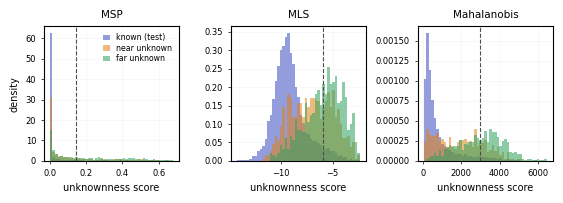

In [ ]:
figure,axes=plt.subplots(1,3,figsize=(5.5,1.9))
PANELS=[("msp","MSP"),("mls","MLS"),("mahalanobis","Mahalanobis")]
for axis,(score_name,title) in zip(axes,PANELS):
    scores=SCORES[f"vanilla_{score_name}"]
    low=float(min(scores["test"].min(),scores["near"].min(),scores["far"].min()))
    high=float(max(np.percentile(scores["test"],99.5),np.percentile(scores["near"],99.5),
                   np.percentile(scores["far"],99.5)))
    bins=np.linspace(low,high,50)
    axis.hist(scores["test"],bins=bins,density=True,alpha=0.55,label="known (test)",color="#3b4cc0")
    axis.hist(scores["near"],bins=bins,density=True,alpha=0.55,label="near unknown",color="#e08214")
    axis.hist(scores["far"],bins=bins,density=True,alpha=0.55,label="far unknown",color="#2ca25f")
    axis.axvline(RESULTS[f"vanilla_{score_name}"]["threshold"],ls="--",lw=0.8,color="0.3")
    axis.set_title(title,fontsize=7.5)
    axis.set_xlabel("unknownness score",fontsize=7)
    axis.tick_params(labelsize=6,length=2,width=0.5)
    axis.grid(alpha=0.15,lw=0.4)
axes[0].set_ylabel("density",fontsize=7)
axes[0].legend(frameon=False,fontsize=5.6,handlelength=0.9,labelspacing=0.2)
figure.tight_layout(pad=0.25,w_pad=0.7)
figure.savefig("task4/results/figures/score_distributions.pdf",bbox_inches="tight")
plt.show()

In [ ]:
summary={"seed":SEED,"known_classes":KNOWN_CLASSES,
         "near_classes":NEAR_CLASSES,"far_classes":FAR_CLASSES,
         "hyperparameters":CONFIG,
         "closed_set_accuracy":CSA,
         "results":RESULTS,"failures":FAILURES,
         "unknown_prediction_counts":{},
         "histories":HISTORIES}
for group_name in ["near","far"]:
    predictions=CACHE["vanilla"][group_name]["logits"].argmax(1).numpy()
    counts=np.bincount(predictions,minlength=len(KNOWN_CLASSES))
    summary["unknown_prediction_counts"][group_name]={KNOWN_CLASSES[i]:int(counts[i])
                                                       for i in range(len(KNOWN_CLASSES))}
json.dump(summary,open("task4/results/task4_results.json","w"),indent=1)
print("wrote task4/results/task4_results.json")

wrote task4/results/task4_results.json
